Exploratory Data Analysis for Pneumonia Detection from Chest X-Ray Images.

The goal of this notebook is to investigate the structure and properties of the
dataset before training a Convolutional Neural Network (CNN). The analysis
identifies issues such as class imbalance, unreliable dataset splits,
image inconsistencies, and potential data quality problems.

Insights obtained here will guide preprocessing, dataset restructuring,
and CNN architecture choices.


In [1]:
### Import Libraries

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import tensorflow as tf
import keras
from keras import layers

#from tensorflow.keras import layers

from tensorflow.keras import layers, models, regularizers

keras.utils.set_random_seed(42)
np.random.seed(42)
random.seed(42)

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)

TensorFlow: 2.19.0
Keras: 3.13.2


In [2]:
# Clone the functions repository into CSCK506
# If it exists, pull the repository
from google.colab import userdata
import os

token = userdata.get("GITHUB_TOKEN")
repo = "osamadev/pneumonia-classification-project"

!([ -d "pneumonia-classification-project" ] && \
cd pneumonia-classification-project && git pull) || git clone -b eyapene --single-branch https://{token}@github.com/{repo}.git

Cloning into 'pneumonia-classification-project'...
remote: Enumerating objects: 85, done.
remote: Counting objects: 100% (85/85), done.
remote: Compressing objects: 100% (65/65), done.
remote: Total 85 (delta 33), reused 6 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (85/85), 1.51 MiB | 4.32 MiB/s, done.
Resolving deltas: 100% (33/33), done.


In [3]:
import sys
import importlib

# Point to the folder containing the 'helpers' folder
sys.path.append('/content/pneumonia-classification-project/')

# import the functions from utilities
from helpers import utilities as utils

# Reload the module to reflect changes without restarting the kernel
importlib.reload(utils)

<module 'helpers.utilities' from '/content/pneumonia-classification-project/helpers/utilities.py'>

In [4]:
### Install if not yet to explore data path

!command -v tree >/dev/null 2>&1 || apt-get -qq install tree

Selecting previously unselected package tree.
(Reading database ... 121852 files and directories currently installed.)
Preparing to unpack .../tree_2.0.2-1_amd64.deb ...
Unpacking tree (2.0.2-1) ...
Setting up tree (2.0.2-1) ...
Processing triggers for man-db (2.10.2-1) ...


In [5]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("GPU detected:", gpus)
    try:
        # Set memory growth **before any tensors are allocated**
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)
else:
    print("No GPU detected, using CPU")

GPU detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Physical devices cannot be modified after being initialized


In [6]:
### Download the data

import kagglehub

path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Dataset path:", path)
!tree -d -L 3 {path}

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Dataset path: /kaggle/input/chest-xray-pneumonia
/kaggle/input/chest-xray-pneumonia
└── chest_xray
    ├── chest_xray
    │   ├── test
    │   ├── train
    │   └── val
    ├── __MACOSX
    │   └── chest_xray
    ├── test
    │   ├── NORMAL
    │   └── PNEUMONIA
    ├── train
    │   ├── NORMAL
    │   └── PNEUMONIA
    └── val
        ├── NORMAL
        └── PNEUMONIA

16 directories


In [7]:
### Dataset Directory Setup

dataset_path = os.path.join(path, "chest_xray")

train_dir = os.path.join(dataset_path, "train")
val_dir = os.path.join(dataset_path, "val")
test_dir = os.path.join(dataset_path, "test")

splits = {
    "train": train_dir,
    "val": val_dir,
    "test": test_dir
}

classes = ["NORMAL", "PNEUMONIA"]

In [8]:
### Dataset Structure Analysis
### Count images in each split

data = []

for split, path in splits.items():
    normal = len(os.listdir(os.path.join(path, "NORMAL")))
    pneumonia = len(os.listdir(os.path.join(path, "PNEUMONIA")))

    data.append([split, normal, pneumonia, normal + pneumonia])

df = pd.DataFrame(data, columns=["Split", "NORMAL", "PNEUMONIA", "TOTAL"])
df

,Split,NORMAL,PNEUMONIA,TOTAL
0,train,1341,3875,5216
1,val,8,8,16
2,test,234,390,624


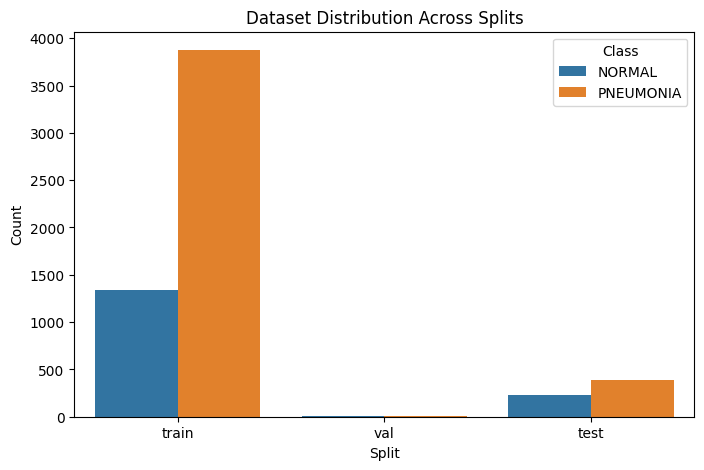

In [9]:
### Visualize Dataset Distribution
df_plot = df.melt("Split", var_name="Class", value_name="Count").query("Class!='TOTAL'")

plt.figure(figsize=(8,5))

sns.barplot(
    data=df_plot,
    x="Split",
    y="Count",
    hue="Class"
)

plt.title("Dataset Distribution Across Splits")
plt.show()

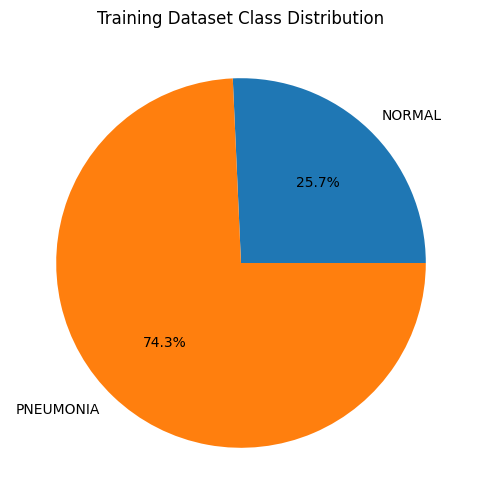

In [10]:
train_counts = df_plot[df_plot.Split == "train"]

plt.figure(figsize=(6,6))

plt.pie(
    train_counts["Count"],
    labels=train_counts["Class"],
    autopct='%1.1f%%'
)

plt.title("Training Dataset Class Distribution")
plt.show()

Observation:
- Extremely Small Validation Set: The validation dataset contains only 16 images.
The validation set must then be reconstructed by splitting the training dataset.

- Severe Class Imbalance in training: The training dataset has approximately a 3:1 imbalance (Normal ≈ 26% and Pneumonia ≈ 74%)
We must use class weighting and data augmentation to reduce class bias.

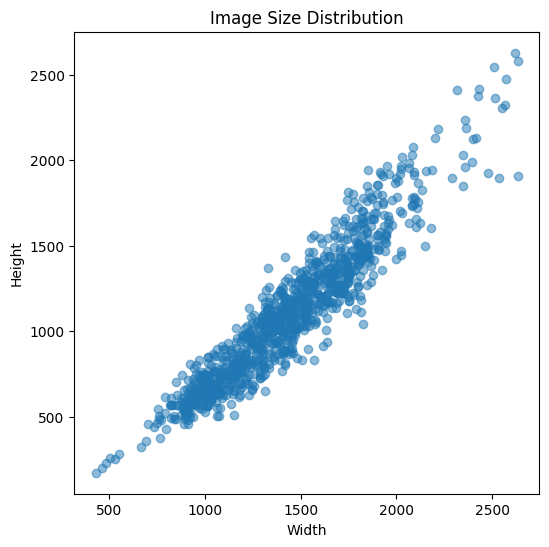

In [11]:
### Image Dimension Analysis

sizes = []

for cls in classes:
    folder = os.path.join(train_dir, cls)

    for img_file in os.listdir(folder)[:500]:

        img_path = os.path.join(folder, img_file)
        img = Image.open(img_path)

        sizes.append(img.size)

sizes = np.array(sizes)

# Plot size distribution
plt.figure(figsize=(6,6))

plt.scatter(sizes[:,0], sizes[:,1], alpha=0.5)

plt.xlabel("Width")
plt.ylabel("Height")
plt.title("Image Size Distribution")

plt.show()

Images appear in multiple resolutions. For modelling our CNN, we will resized them into a constant size of 224 x 224 to enhance model performance and training efficiency

In [12]:
### Check whether images are RGB or grayscale

for split, path in splits.items():
    for cls in ["NORMAL", "PNEUMONIA"]:
        img_path = os.path.join(path, cls, os.listdir(os.path.join(path, cls))[0])
        img = Image.open(img_path)
        print(split, cls, img.mode)

train NORMAL L
train PNEUMONIA L
val NORMAL L
val PNEUMONIA L
test NORMAL L
test PNEUMONIA L


Images are all grayscales images

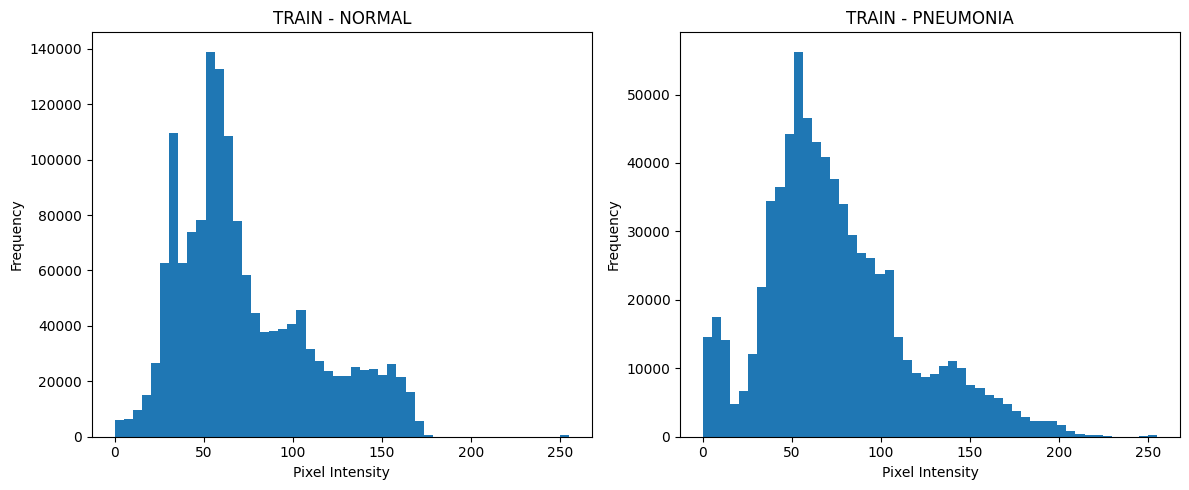

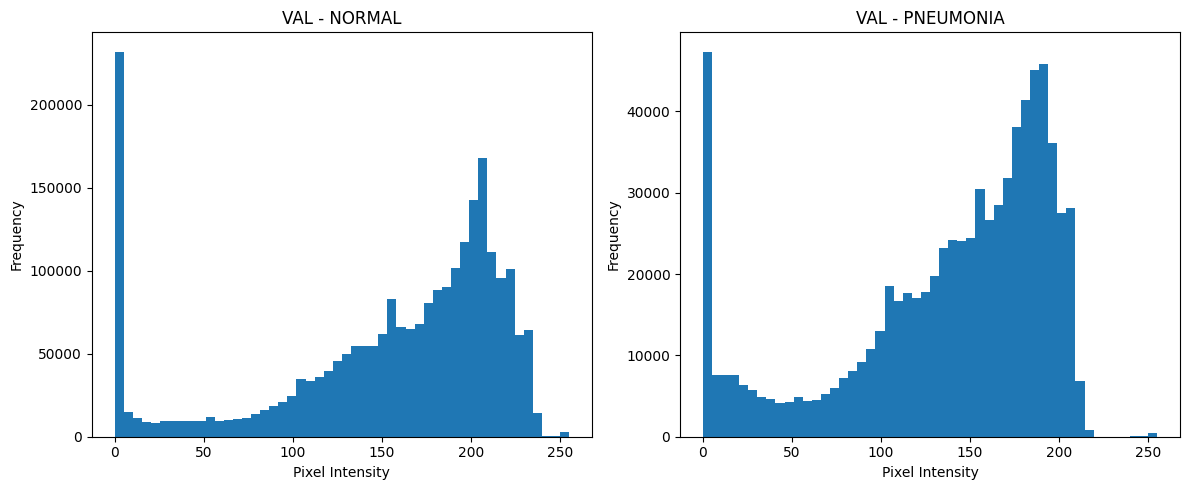

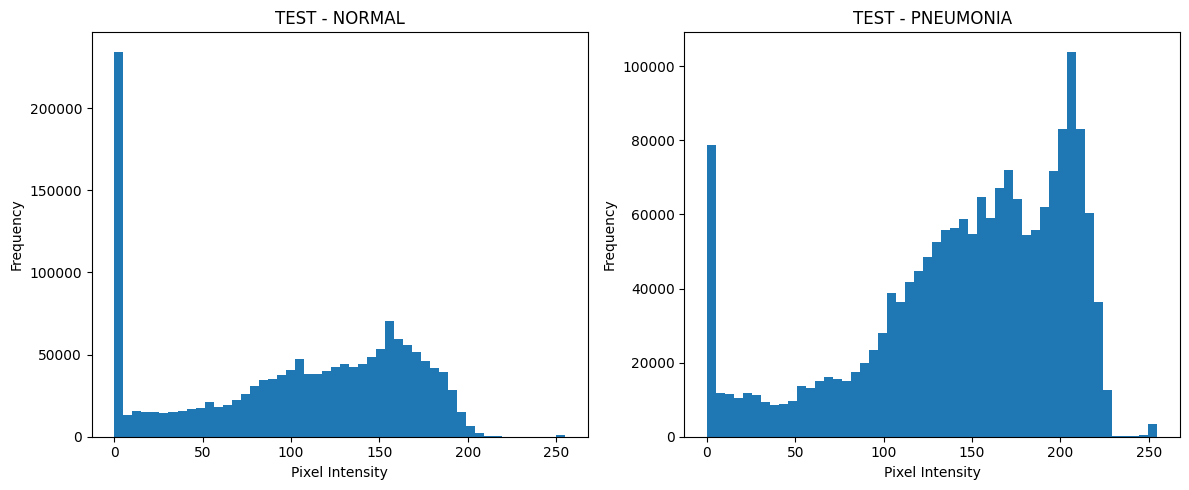

In [13]:
"""img_array = np.array(sample_image)

plt.hist(img_array.flatten(), bins=50)

plt.title("Pixel Intensity Distribution")

plt.show()
"""
for split, path in splits.items():
    plt.figure(figsize=(12, 5))  # wider figure for side-by-side plots

    for i, cls in enumerate(["NORMAL", "PNEUMONIA"]):
        # Load first image of each class
        img_path = os.path.join(path, cls, os.listdir(os.path.join(path, cls))[0])
        img = Image.open(img_path)
        img_array = np.array(img)

        # Plot side by side
        plt.subplot(1, 2, i + 1)
        plt.hist(img_array.flatten(), bins=50)
        plt.title(f"{split.upper()} - {cls}")
        plt.xlabel("Pixel Intensity")
        plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

Images values are typically range between 0 – 255. Pixel values will be normalized to [0,1] during preprocessing.

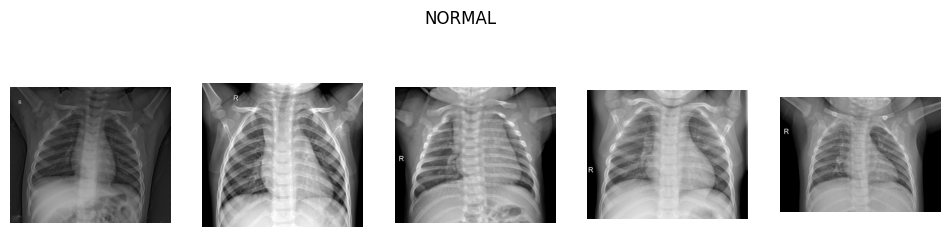

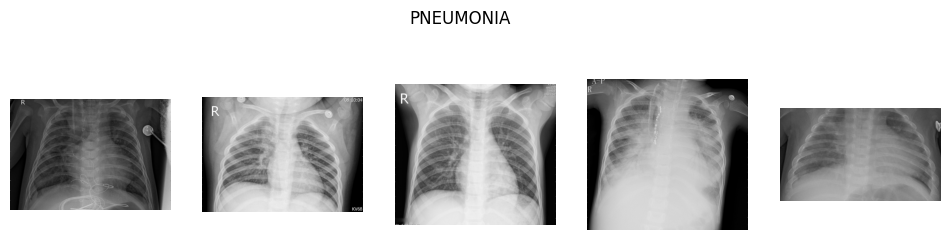

In [14]:
utils.show_samples("NORMAL", train_dir)
utils.show_samples("PNEUMONIA", train_dir)

In [15]:
corrupted = []

for split_name, split_path in splits.items():

    for cls in classes:

        folder = os.path.join(split_path, cls)

        for file in os.listdir(folder):

            path_img = os.path.join(folder, file)

            try:
                img = Image.open(path_img)
                img.verify()

            except:
                corrupted.append(path_img)

print("Corrupted images:", len(corrupted))

Corrupted images: 0


There is 0 corruped images

In [16]:
import hashlib

hashes = {}
duplicates = []

for split_name, split_path in splits.items():

    for cls in classes:

        folder = os.path.join(split_path, cls)

        for file in os.listdir(folder):

            path_img = os.path.join(folder, file)

            with open(path_img, "rb") as f:
                filehash = hashlib.md5(f.read()).hexdigest()

            if filehash in hashes:
                duplicates.append(path_img)
            else:
                hashes[filehash] = path_img

print("Duplicate images:", len(duplicates))

Duplicate images: 32


There a few duplicates images: 32

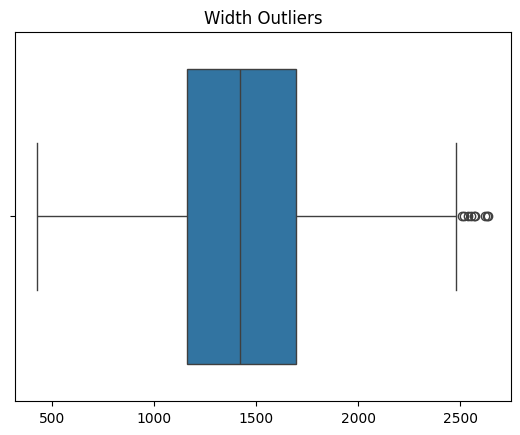

In [17]:
widths = sizes[:,0]
heights = sizes[:,1]

sns.boxplot(x=widths)
plt.title("Width Outliers")
plt.show()

In [18]:
normal_brightness = utils.compute_brightness(os.path.join(train_dir,"NORMAL"))
pneumonia_brightness = utils.compute_brightness(os.path.join(train_dir,"PNEUMONIA"))

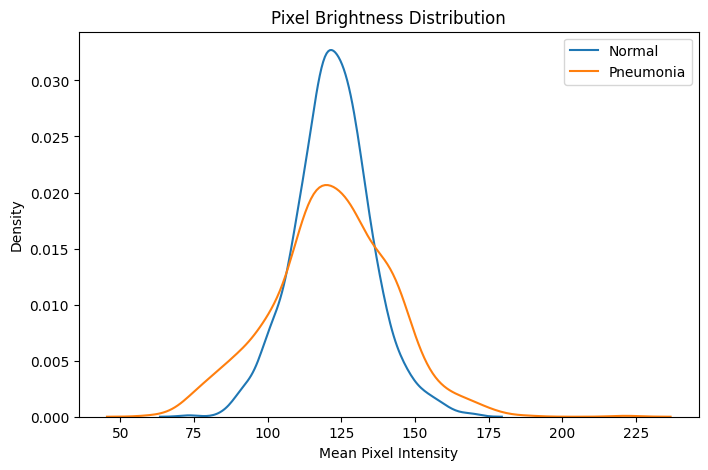

In [19]:
plt.figure(figsize=(8,5))

sns.kdeplot(normal_brightness, label="Normal")
sns.kdeplot(pneumonia_brightness, label="Pneumonia")

plt.title("Pixel Brightness Distribution")
plt.xlabel("Mean Pixel Intensity")
plt.legend()
plt.show()

Normal images typically show higher average brightness.

In [20]:
normal_entropy = utils.compute_entropy(os.path.join(train_dir,"NORMAL"))
pneumonia_entropy = utils.compute_entropy(os.path.join(train_dir,"PNEUMONIA"))

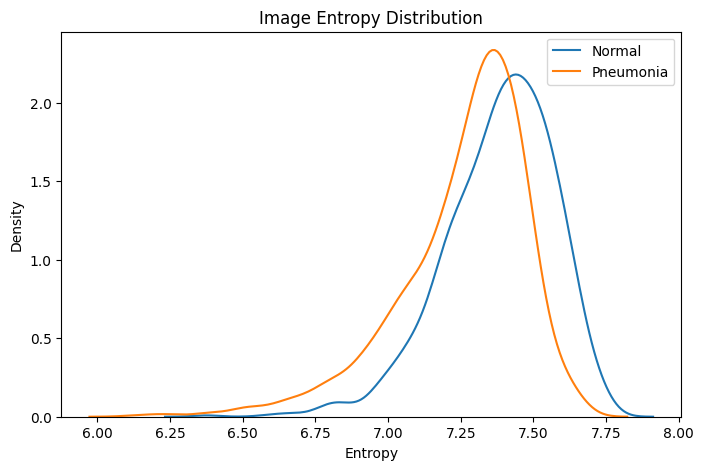

In [21]:
plt.figure(figsize=(8,5))

sns.kdeplot(normal_entropy,label="Normal")
sns.kdeplot(pneumonia_entropy,label="Pneumonia")

plt.title("Image Entropy Distribution")
plt.xlabel("Entropy")

plt.legend()
plt.show()

Images exhibit higher entropy due to irregular textures. This means CNN models must capture complex texture patterns rather than simple edges.

In [22]:
normal_texture = utils.compute_texture(os.path.join(train_dir,"NORMAL"))
pneumonia_texture = utils.compute_texture(os.path.join(train_dir,"PNEUMONIA"))

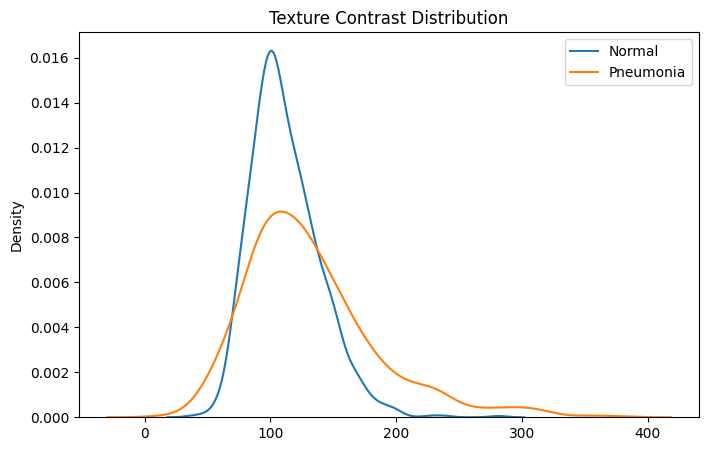

In [23]:
plt.figure(figsize=(8,5))

sns.kdeplot(normal_texture,label="Normal")
sns.kdeplot(pneumonia_texture,label="Pneumonia")

plt.title("Texture Contrast Distribution")

plt.legend()
plt.show()

Normal images show higher texture variability.

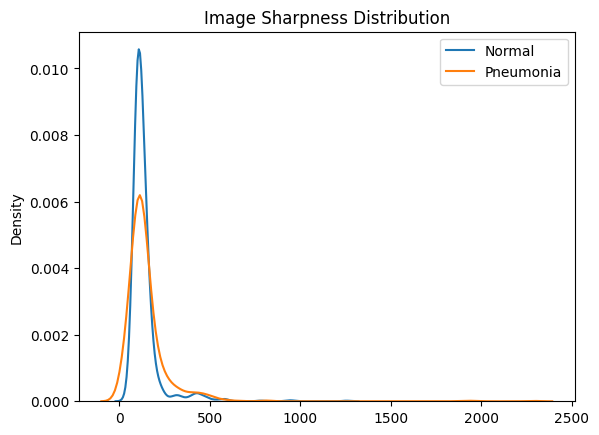

In [24]:
normal_sharp = utils.compute_sharpness(os.path.join(train_dir,"NORMAL"))
pneumonia_sharp = utils.compute_sharpness(os.path.join(train_dir,"PNEUMONIA"))

sns.kdeplot(normal_sharp,label="Normal")
sns.kdeplot(pneumonia_sharp,label="Pneumonia")

plt.title("Image Sharpness Distribution")
plt.legend()
plt.show()

Some images show significantly lower sharpness, indicating acquisition variability.
Image augmentation and normalization may improve robustness.

Brightness distributions differ slightly between train and test. Normalization and augmentation will be useful.

| Analysis     | Insight                         | Modelling Impact        |
| ------------ | ------------------------------- | ----------------------- |
| Brightness   | Pneumonia lungs appear brighter | Contrast normalization  |
| Entropy      | Pneumonia scans more complex    | CNN texture learning    |
| Texture      | Structural differences          | Deep feature extraction |
| Sharpness    | Variable image quality          | Robust augmentation     |
| Dataset bias | Potential distribution shift    | Careful normalization   |


**Summary:**

The exploratory analysis revealed several important characteristics of the dataset:

Validation dataset is extremely small (16 images), making it unsuitable for reliable model selection. Therefore the validation set will be reconstructed from the training data.

Significant class imbalance exists, with pneumonia cases representing approximately 74% of the training data. Class weighting and data augmentation will be used to mitigate this issue.

Image dimensions vary considerably, requiring resizing to a consistent resolution before training.

Images are stored in grayscale format, and will be normalized and converted to a CNN-compatible representation.

These insights directly inform the design of the preprocessing pipeline and the architecture of the convolutional neural network used for pneumonia detection.

## Preprocessing (without augmentation)

In [25]:
X_train, y_train = utils.load_dataset(train_dir, "Train")

Train images: 5216
Train Normal: 1341
Train Pneumonia: 3875


In [26]:
X_val, y_val = utils.load_dataset(val_dir, "Validation")

Validation images: 16
Validation Normal: 8
Validation Pneumonia: 8


In [27]:
X_test, y_test = utils.load_dataset(test_dir, "Test")

Test images: 624
Test Normal: 234
Test Pneumonia: 390


In [28]:
train_dataset = utils.build_dataset(X_train, y_train)

val_dataset = utils.build_dataset(X_val, y_val)

test_dataset = utils.build_dataset(X_test, y_test)

In [29]:
class_weights = utils.get_class_weights(y_train)
print(class_weights)

{0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}


In [30]:
for images, labels in train_dataset.take(1):
    print(images.shape)
    print(labels.shape)

(32, 224, 224, 1)
(32,)


## Baseline Model - Without augmentation

In [31]:
baseline_model_val_raw = utils.build_baseline_model()

baseline_model_val_raw.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 112, 112,  │      1,600 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 112, 112,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 112, 112,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 56, 56,    │          0 │ re_lu[0][0]       │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 56, 56,    │      9,248 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 56, 56,    │      9,248 │ re_lu_1[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 2)         │         66 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │         96 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1, 32)  │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 56, 56,    │          0 │ multiply[0][0],   │
│                     │ 32)               │            │ max_pooling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 56, 56,    │          0 │ add[0][0]         │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 56, 56,    │      9,248 │ re_lu_2[0][0]   

 Total params: 2,859,773 (10.91 MB)

 Trainable params: 2,854,461 (10.89 MB)

 Non-trainable params: 5,312 (20.75 KB)

In [32]:
baseline_model_val_raw.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),

    loss='binary_crossentropy',

    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall()
    ]
)

In [33]:
baseline_model_val_raw.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),

    loss='binary_crossentropy',

    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall()
    ]
)

In [34]:
callbacks = utils.get_callbacks()
history = baseline_model_val_raw.fit(

    train_dataset,

    validation_data=val_dataset,

    epochs=30,

    class_weight=class_weights,

    callbacks=callbacks
)

Epoch 1/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.7938 - auc: 0.5660 - loss: 0.8169 - precision_1: 0.5823 - recall_1: 0.4041
Epoch 1: val_auc improved from None to 0.50000, saving model to best_cxr_model.h5



Epoch 1: finished saving model to best_cxr_model.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 45s 88ms/step - accuracy: 0.8526 - auc: 0.9186 - loss: 0.5867 - precision_1: 0.9720 - recall_1: 0.8253 - val_accuracy: 0.5000 - val_auc: 0.5000 - val_loss: 1.8265 - val_precision_1: 0.5000 - val_recall_1: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.6012 - auc: 0.4656 - loss: 1.9746 - precision_1: 0.4603 - recall_1: 0.3603
Epoch 2: val_auc did not improve from 0.50000
163/163 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - accuracy: 0.7766 - auc: 0.8044 - loss: 0.9066 - precision_1: 0.9007 - recall_1: 0.7861 - val_accuracy: 0.5000 - val_auc: 0.5000 - val_loss: 2.7935 - val_precision_1: 0.5000 - val_recall_1: 1.0000 - learning_rate: 1.0000e-04
Epoch 3/30
162/163 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.6252 - auc: 0.4895 - loss: 1.7676 - precision_1: 0.4777 - recall_1: 0.3966
Epoch 3: val_auc improved from 0.50000 to 0.65625, saving model to best_cxr_mod


Epoch 3: finished saving model to best_cxr_model.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 11s 66ms/step - accuracy: 0.8025 - auc: 0.8290 - loss: 0.8321 - precision_1: 0.9054 - recall_1: 0.8199 - val_accuracy: 0.5000 - val_auc: 0.6562 - val_loss: 1.6208 - val_precision_1: 0.5000 - val_recall_1: 1.0000 - learning_rate: 1.0000e-04
Epoch 4/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.6624 - auc: 0.5307 - loss: 1.5178 - precision_1: 0.5058 - recall_1: 0.3949
Epoch 4: val_auc did not improve from 0.65625
163/163 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - accuracy: 0.8112 - auc: 0.8596 - loss: 0.7451 - precision_1: 0.9248 - recall_1: 0.8119 - val_accuracy: 0.4375 - val_auc: 0.6562 - val_loss: 1.5223 - val_precision_1: 0.4667 - val_recall_1: 0.8750 - learning_rate: 1.0000e-04
Epoch 5/30
162/163 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.6007 - auc: 0.4921 - loss: 1.7388 - precision_1: 0.4587 - recall_1: 0.3526
Epoch 5: val_auc did not improve from 0.65625
163/163 ━━━━━━━━━━━━━━━━━━━━ 10s 

In [35]:
test_loss, test_acc, test_auc, test_precision, test_recall = baseline_model_val_raw.evaluate(test_dataset)

print("\nTest Performance")
print("---------------------")

print(f"Test Loss      : {test_loss:.4f}")
print(f"Test Accuracy  : {test_acc:.4f}")
print(f"Test AUC       : {test_auc:.4f}")
print(f"Test Precision : {test_precision:.4f}")
print(f"Test Recall    : {test_recall:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.6266 - auc: 0.6371 - loss: 1.3808 - precision_1: 0.6260 - recall_1: 1.0000

Test Performance
---------------------
Test Loss      : 1.3808
Test Accuracy  : 0.6266
Test AUC       : 0.6371
Test Precision : 0.6260
Test Recall    : 1.0000


In [36]:
y_true, y_pred_probs, y_pred = utils.get_predictions(baseline_model_val_raw, test_dataset, threshold=0.3)

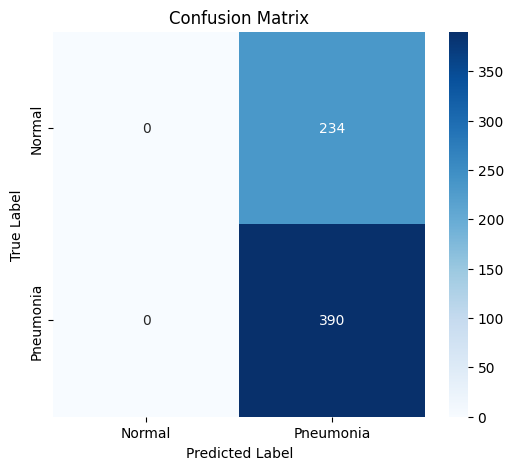

In [37]:
labels = ["Normal", "Pneumonia"]
utils.plot_confusion_matrix(y_true, y_pred, labels=labels)

In [38]:
y_true, y_pred_probs, y_pred = utils.get_predictions_with_tf(baseline_model_val_raw, test_dataset)

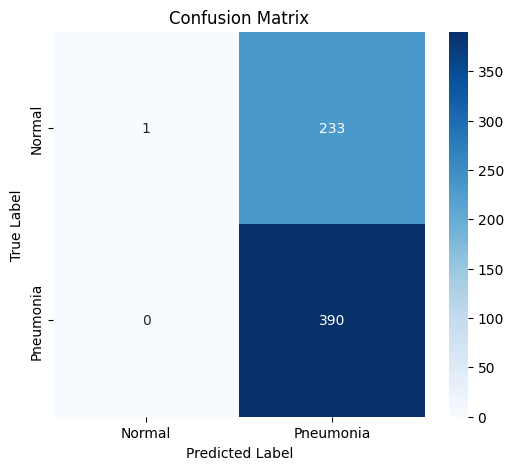

In [39]:
labels = ["Normal", "Pneumonia"]
utils.plot_confusion_matrix(y_true, y_pred, labels=labels)

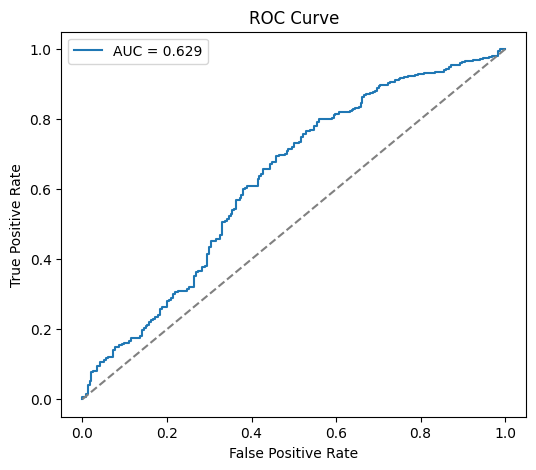

In [40]:
fpr, tpr, roc_auc = utils.plot_roc_curve(y_true, y_pred_probs)

In [41]:
last_conv_layer = utils.get_last_conv_layer(baseline_model_val_raw)
print("Last conv layer:", last_conv_layer)

Last conv layer: conv2d_19


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 1))
  warnings.warn(msg)


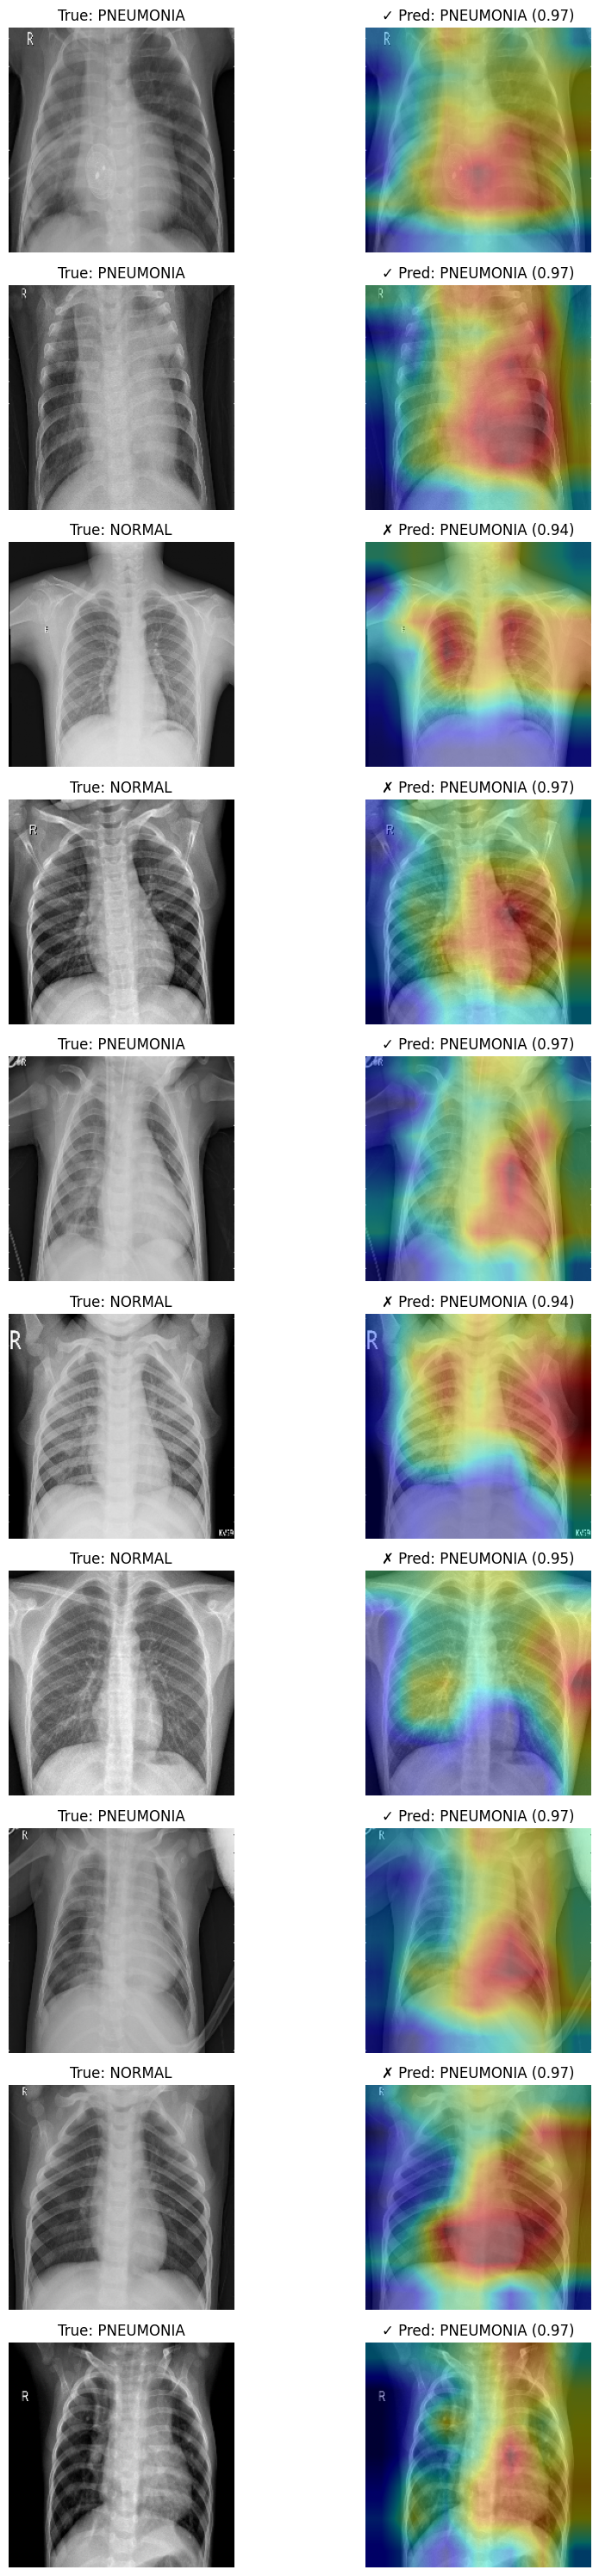

In [42]:
# Visualize Grad-CAM
utils.visualize_gradcam_samples(
    model=baseline_model_val_raw,
    dataset=test_dataset,
    last_conv_layer_name=last_conv_layer,
    class_names=["NORMAL", "PNEUMONIA"],
    num_images=10
)

## Preprocessing (with augmentation)

In [43]:
import numpy as np
from sklearn.model_selection import train_test_split

# Combine train and validation sets
X_all = np.concatenate([X_train, X_val], axis=0)
y_all = np.concatenate([y_train, y_val], axis=0)

# Resplit with 15% validation
X_train, X_val, y_train, y_val = train_test_split(
    X_all,
    y_all,
    test_size=0.15,
    random_state=42,
    shuffle=True,
    stratify=y_all
)


In [44]:
len(X_train)

4447

In [45]:
len(X_val)

785

In [46]:
train_dataset = utils.build_dataset(X_train, y_train, augmentation=True)
val_dataset = utils.build_dataset(X_val, y_val)

In [47]:
class_weights_aug = utils.get_class_weights(y_train)
print(class_weights)

{0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}


## Baseline Model - With augmentation

In [48]:
baseline_model_val_aug = utils.build_baseline_model()

baseline_model_val_aug.summary()

Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 112, 112,  │      1,600 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        128 │ conv2d_20[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_17 (ReLU)     │ (None, 112, 112,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 56, 56,    │          0 │ re_lu_17[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 56, 56,    │      9,248 │ max_pooling2d_1[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        128 │ conv2d_21[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_18 (ReLU)     │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 56, 56,    │      9,248 │ re_lu_18[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        128 │ conv2d_22[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 2)         │         66 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 32)        │         96 │ dense_18[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_8 (Reshape) │ (None, 1, 1, 32)  │          0 │ dense_19[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_8          │ (None, 56, 56,    │          0 │ batch_normalizat… │
│ (Multiply)          │ 32)               │            │ reshape_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_8 (Add)         │ (None, 56, 56,    │          0 │ multiply_8[0][0], │
│                     │ 32)               │            │ max_pooling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_19 (ReLU)     │ (None, 56, 56,    │          0 │ add_8[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 56, 56,    │      9,248 │ re_lu_19[0][0]  

 Total params: 2,859,773 (10.91 MB)

 Trainable params: 2,854,461 (10.89 MB)

 Non-trainable params: 5,312 (20.75 KB)

In [49]:
baseline_model_val_aug.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),

    loss='binary_crossentropy',

    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall()
    ]
)

In [50]:
baseline_model_val_aug.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),

    loss='binary_crossentropy',

    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall()
    ]
)

In [51]:
callbacks = utils.get_callbacks()
history_baseline_model_val_aug = baseline_model_val_aug.fit(

    train_dataset,

    validation_data=val_dataset,

    epochs=30,

    class_weight=class_weights_aug,

    callbacks=callbacks
)

Epoch 1/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.7746 - auc: 0.8764 - loss: 0.6564 - precision_3: 0.9405 - recall_3: 0.7433
Epoch 1: val_auc improved from None to 0.46376, saving model to best_cxr_model.h5



Epoch 1: finished saving model to best_cxr_model.h5
139/139 ━━━━━━━━━━━━━━━━━━━━ 65s 234ms/step - accuracy: 0.8289 - auc: 0.9196 - loss: 0.5650 - precision_3: 0.9568 - recall_3: 0.8058 - val_accuracy: 0.7427 - val_auc: 0.4638 - val_loss: 1.1263 - val_precision_3: 0.7427 - val_recall_3: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.8729 - auc: 0.9466 - loss: 0.4913 - precision_3: 0.9684 - recall_3: 0.8586
Epoch 2: val_auc improved from 0.46376 to 0.50000, saving model to best_cxr_model.h5



Epoch 2: finished saving model to best_cxr_model.h5
139/139 ━━━━━━━━━━━━━━━━━━━━ 19s 99ms/step - accuracy: 0.8815 - auc: 0.9528 - loss: 0.4715 - precision_3: 0.9686 - recall_3: 0.8685 - val_accuracy: 0.7427 - val_auc: 0.5000 - val_loss: 2.3292 - val_precision_3: 0.7427 - val_recall_3: 1.0000 - learning_rate: 1.0000e-04
Epoch 3/30
138/139 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.9091 - auc: 0.9681 - loss: 0.4207 - precision_3: 0.9795 - recall_3: 0.8960
Epoch 3: val_auc did not improve from 0.50000
139/139 ━━━━━━━━━━━━━━━━━━━━ 18s 96ms/step - accuracy: 0.9101 - auc: 0.9666 - loss: 0.4277 - precision_3: 0.9773 - recall_3: 0.8997 - val_accuracy: 0.7427 - val_auc: 0.5000 - val_loss: 2.2552 - val_precision_3: 0.7427 - val_recall_3: 1.0000 - learning_rate: 1.0000e-04
Epoch 4/30
138/139 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.8832 - auc: 0.9613 - loss: 0.4412 - precision_3: 0.9663 - recall_3: 0.8741
Epoch 4: val_auc improved from 0.50000 to 0.94710, saving model to best_cxr_mod


Epoch 4: finished saving model to best_cxr_model.h5
139/139 ━━━━━━━━━━━━━━━━━━━━ 19s 97ms/step - accuracy: 0.9011 - auc: 0.9700 - loss: 0.4134 - precision_3: 0.9719 - recall_3: 0.8924 - val_accuracy: 0.8242 - val_auc: 0.9471 - val_loss: 0.7246 - val_precision_3: 0.8121 - val_recall_3: 0.9931 - learning_rate: 1.0000e-04
Epoch 5/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.9201 - auc: 0.9769 - loss: 0.3830 - precision_3: 0.9810 - recall_3: 0.9106
Epoch 5: val_auc improved from 0.94710 to 0.97165, saving model to best_cxr_model.h5



Epoch 5: finished saving model to best_cxr_model.h5
139/139 ━━━━━━━━━━━━━━━━━━━━ 19s 99ms/step - accuracy: 0.9190 - auc: 0.9757 - loss: 0.3918 - precision_3: 0.9791 - recall_3: 0.9103 - val_accuracy: 0.9185 - val_auc: 0.9716 - val_loss: 0.4133 - val_precision_3: 0.9061 - val_recall_3: 0.9931 - learning_rate: 1.0000e-04
Epoch 6/30
138/139 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.9192 - auc: 0.9763 - loss: 0.3897 - precision_3: 0.9802 - recall_3: 0.9090
Epoch 6: val_auc improved from 0.97165 to 0.98822, saving model to best_cxr_model.h5



Epoch 6: finished saving model to best_cxr_model.h5
139/139 ━━━━━━━━━━━━━━━━━━━━ 19s 99ms/step - accuracy: 0.9226 - auc: 0.9789 - loss: 0.3765 - precision_3: 0.9792 - recall_3: 0.9152 - val_accuracy: 0.8293 - val_auc: 0.9882 - val_loss: 0.6653 - val_precision_3: 0.9978 - val_recall_3: 0.7719 - learning_rate: 1.0000e-04
Epoch 7/30
138/139 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.9306 - auc: 0.9796 - loss: 0.3730 - precision_3: 0.9813 - recall_3: 0.9256
Epoch 7: val_auc did not improve from 0.98822
139/139 ━━━━━━━━━━━━━━━━━━━━ 18s 96ms/step - accuracy: 0.9296 - auc: 0.9790 - loss: 0.3769 - precision_3: 0.9810 - recall_3: 0.9230 - val_accuracy: 0.8866 - val_auc: 0.9781 - val_loss: 0.4608 - val_precision_3: 0.8698 - val_recall_3: 0.9966 - learning_rate: 1.0000e-04
Epoch 8/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.9270 - auc: 0.9820 - loss: 0.3620 - precision_3: 0.9815 - recall_3: 0.9190
Epoch 8: val_auc did not improve from 0.98822
139/139 ━━━━━━━━━━━━━━━━━━━━ 19s 


Epoch 10: finished saving model to best_cxr_model.h5
139/139 ━━━━━━━━━━━━━━━━━━━━ 19s 98ms/step - accuracy: 0.9433 - auc: 0.9861 - loss: 0.3414 - precision_3: 0.9817 - recall_3: 0.9412 - val_accuracy: 0.9707 - val_auc: 0.9931 - val_loss: 0.2883 - val_precision_3: 0.9714 - val_recall_3: 0.9897 - learning_rate: 3.0000e-05
Epoch 11/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.9400 - auc: 0.9857 - loss: 0.3425 - precision_3: 0.9836 - recall_3: 0.9352
Epoch 11: val_auc did not improve from 0.99306
139/139 ━━━━━━━━━━━━━━━━━━━━ 19s 98ms/step - accuracy: 0.9490 - auc: 0.9884 - loss: 0.3254 - precision_3: 0.9849 - recall_3: 0.9458 - val_accuracy: 0.9248 - val_auc: 0.9925 - val_loss: 0.4014 - val_precision_3: 0.9962 - val_recall_3: 0.9022 - learning_rate: 3.0000e-05
Epoch 12/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.9467 - auc: 0.9884 - loss: 0.3246 - precision_3: 0.9818 - recall_3: 0.9463
Epoch 12: val_auc improved from 0.99306 to 0.99514, saving model to best_cx


Epoch 12: finished saving model to best_cxr_model.h5
139/139 ━━━━━━━━━━━━━━━━━━━━ 19s 100ms/step - accuracy: 0.9458 - auc: 0.9881 - loss: 0.3278 - precision_3: 0.9820 - recall_3: 0.9442 - val_accuracy: 0.9732 - val_auc: 0.9951 - val_loss: 0.2716 - val_precision_3: 0.9828 - val_recall_3: 0.9811 - learning_rate: 3.0000e-05
Epoch 13/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.9451 - auc: 0.9874 - loss: 0.3300 - precision_3: 0.9832 - recall_3: 0.9425
Epoch 13: val_auc did not improve from 0.99514
139/139 ━━━━━━━━━━━━━━━━━━━━ 19s 97ms/step - accuracy: 0.9420 - auc: 0.9866 - loss: 0.3341 - precision_3: 0.9826 - recall_3: 0.9385 - val_accuracy: 0.9618 - val_auc: 0.9902 - val_loss: 0.2956 - val_precision_3: 0.9809 - val_recall_3: 0.9674 - learning_rate: 3.0000e-05
Epoch 14/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.9446 - auc: 0.9875 - loss: 0.3313 - precision_3: 0.9825 - recall_3: 0.9434
Epoch 14: val_auc did not improve from 0.99514
139/139 ━━━━━━━━━━━━━━━━━━━

In [52]:
test_loss, test_acc, test_auc, test_precision, test_recall = baseline_model_val_aug.evaluate(test_dataset)

print("\nTest Performance")
print("---------------------")

print(f"Test Loss      : {test_loss:.4f}")
print(f"Test Accuracy  : {test_acc:.4f}")
print(f"Test AUC       : {test_auc:.4f}")
print(f"Test Precision : {test_precision:.4f}")
print(f"Test Recall    : {test_recall:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 145ms/step - accuracy: 0.7885 - auc: 0.9418 - loss: 0.7717 - precision_3: 0.7481 - recall_3: 0.9974

Test Performance
---------------------
Test Loss      : 0.7717
Test Accuracy  : 0.7885
Test AUC       : 0.9418
Test Precision : 0.7481
Test Recall    : 0.9974


In [53]:
y_true, y_pred_probs, y_pred = utils.get_predictions(baseline_model_val_aug, test_dataset, threshold=0.3)

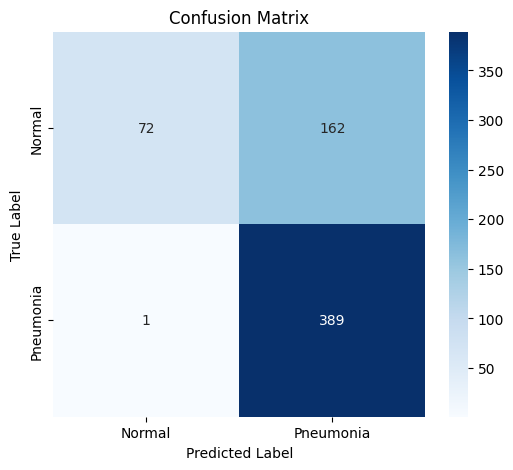

In [54]:
labels = ["Normal", "Pneumonia"]
utils.plot_confusion_matrix(y_true, y_pred, labels=labels)

In [55]:
y_true, y_pred_probs, y_pred = utils.get_predictions_with_tf(baseline_model_val_aug, test_dataset)

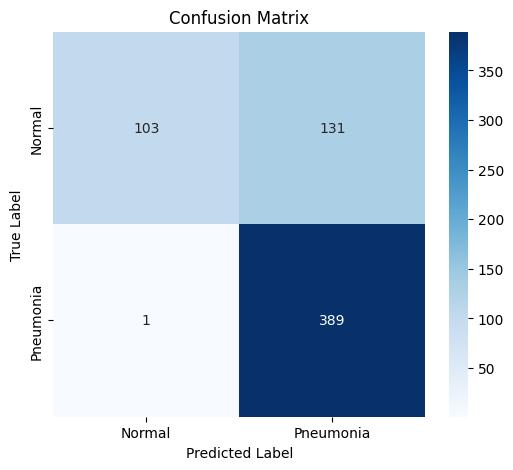

In [56]:
labels = ["Normal", "Pneumonia"]
utils.plot_confusion_matrix(y_true, y_pred, labels=labels)

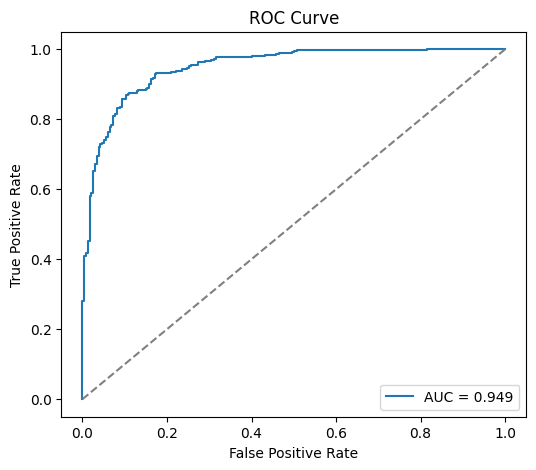

In [57]:
fpr, tpr, roc_auc = utils.plot_roc_curve(y_true, y_pred_probs)

In [58]:
last_conv_layer = utils.get_last_conv_layer(baseline_model_val_aug)
print("Last conv layer:", last_conv_layer)

Last conv layer: conv2d_39


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_118']]
Received: inputs=Tensor(shape=(1, 224, 224, 1))
  warnings.warn(msg)


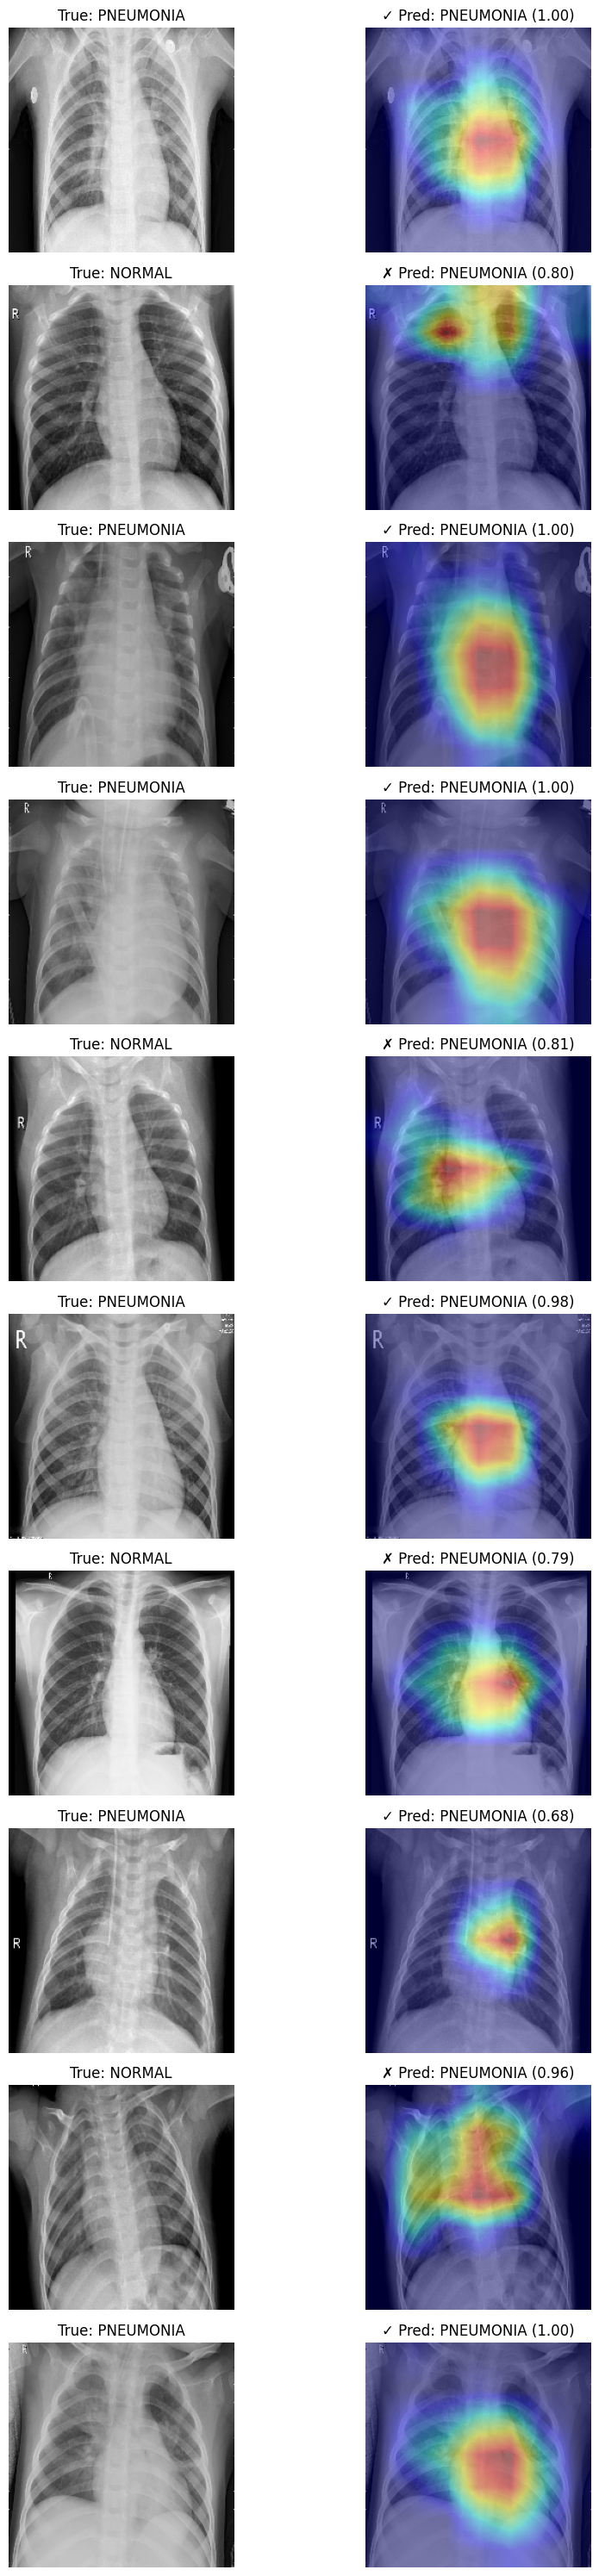

In [59]:
# Visualize Grad-CAM
utils.visualize_gradcam_samples(
    model=baseline_model_val_aug,
    dataset=test_dataset,
    last_conv_layer_name=last_conv_layer,
    class_names=["NORMAL", "PNEUMONIA"],
    num_images=10
)

## Hyperparams Tuned Model

In [60]:
try:
    import keras_tuner as kt
except ImportError:
    !pip install -q keras-tuner
    import keras_tuner as kt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 3.6 MB/s eta 0:00:00


In [61]:
import tensorflow as tf
from tensorflow.keras import layers, models
import keras_tuner as kt

In [62]:
CONFIG = {
    "input_shape": (224, 224, 1),
    "num_stages": {
        "min": 3,
        "max": 4
    },
    "base_filters": [32, 64],
    "se_reduction": [8, 16],
    "dropout": {
        "min": 0.3,
        "max": 0.6,
        "step": 0.1
    },
    "dense_units": [64, 128, 256],
    "l2_reg": [1e-3, 1e-4, 1e-5],
    "learning_rates": [1e-3, 5e-4, 1e-4],
    #"epochs": 10,
    "max_trials": 30
}

In [63]:
tuner = kt.RandomSearch(
    lambda hp: utils.build_tuned_model(hp, CONFIG),
    objective="val_accuracy",
    max_trials=CONFIG["max_trials"],
    directory="hyperparameter_search",
    project_name="pneumonia_cnn"
)

In [64]:
tuning_callbacks = utils.get_callbacks({
    "early_stopping_patience": 4,
    "lr_reduce_patience": 3,
    "checkpoint_path": "tuner_best_model.keras"
})

# Add CSV logger
tuning_callbacks.append(tf.keras.callbacks.CSVLogger("training_log.csv"))

tuner.search(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    callbacks=tuning_callbacks
)

Trial 30 Complete [00h 07m 05s]
val_accuracy: 0.9707006216049194

Best val_accuracy So Far: 0.9745222926139832
Total elapsed time: 02h 36m 36s


In [65]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("Best Hyperparameters Found:")

for hp_name in best_hps.values:
    print(f"{hp_name}: {best_hps.get(hp_name)}")

Best Hyperparameters Found:
base_filters: 64
num_stages: 4
se_reduction: 8
l2_reg: 0.001
dense_units: 128
dropout: 0.3
learning_rate: 0.0001


In [66]:
params_tuned_model = tuner.hypermodel.build(best_hps)

In [73]:
params_tuned_model_callbacks = utils.get_callbacks({
    "early_stopping_patience": 12,
    "lr_reduce_patience": 4,
    "lr_reduce_factor": 0.3,
    "checkpoint_path": "params_tuned_model.keras"
})

In [74]:
history_tuned_model = params_tuned_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=30,
    class_weight=class_weights,
    callbacks=params_tuned_model_callbacks
)

Epoch 1/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - accuracy: 0.9694 - auc: 0.9956 - loss: 2.0568 - precision_3: 0.9944 - recall_3: 0.9645
Epoch 1: val_auc improved from None to 0.99636, saving model to params_tuned_model.keras

Epoch 1: finished saving model to params_tuned_model.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 37s 228ms/step - accuracy: 0.9703 - auc: 0.9958 - loss: 2.0539 - precision_3: 0.9928 - recall_3: 0.9670 - val_accuracy: 0.9236 - val_auc: 0.9964 - val_loss: 2.1831 - val_precision_3: 1.0000 - val_recall_3: 0.8971 - learning_rate: 1.0000e-06
Epoch 2/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.9748 - auc: 0.9967 - loss: 2.0443 - precision_3: 0.9940 - recall_3: 0.9719
Epoch 2: val_auc did not improve from 0.99636
139/139 ━━━━━━━━━━━━━━━━━━━━ 35s 214ms/step - accuracy: 0.9710 - auc: 0.9960 - loss: 2.0523 - precision_3: 0.9907 - recall_3: 0.9700 - val_accuracy: 0.9006 - val_auc: 0.9956 - val_loss: 2.2296 - val_precision_3: 1.0000 - val_recall_3: 0.8662 - learn

In [75]:
test_loss, test_acc, test_auc, test_precision, test_recall = params_tuned_model.evaluate(test_dataset)

print("\nTest Performance")
print("---------------------")

print(f"Test Loss      : {test_loss:.4f}")
print(f"Test Accuracy  : {test_acc:.4f}")
print(f"Test AUC       : {test_auc:.4f}")
print(f"Test Precision : {test_precision:.4f}")
print(f"Test Recall    : {test_recall:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.9215 - auc: 0.9684 - loss: 2.1955 - precision_3: 0.9189 - recall_3: 0.9590

Test Performance
---------------------
Test Loss      : 2.1955
Test Accuracy  : 0.9215
Test AUC       : 0.9684
Test Precision : 0.9189
Test Recall    : 0.9590


In [82]:
y_true, y_pred_probs, y_pred = utils.get_predictions(params_tuned_model, test_dataset, threshold=0.3)

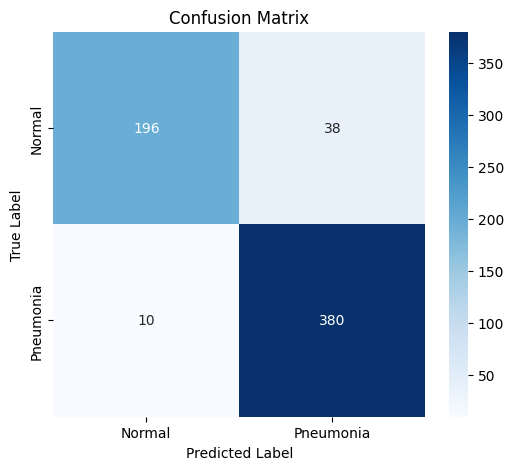

In [83]:
labels = ["Normal", "Pneumonia"]
utils.plot_confusion_matrix(y_true, y_pred, labels=labels)

In [80]:
y_true, y_pred_probs, y_pred = utils.get_predictions_with_tf(params_tuned_model, test_dataset)

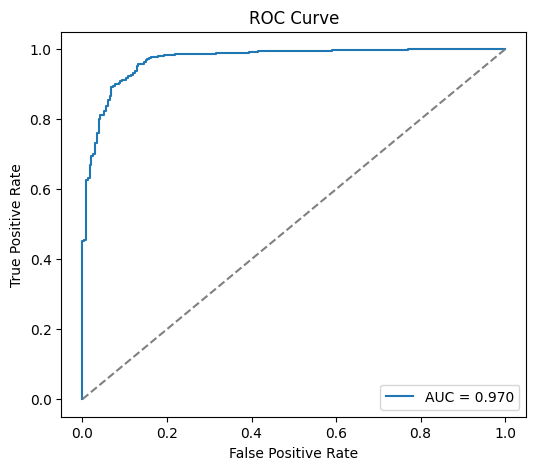

In [84]:
fpr, tpr, roc_auc = utils.plot_roc_curve(y_true, y_pred_probs)

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_148']]
Received: inputs=Tensor(shape=(1, 224, 224, 1))
  warnings.warn(msg)


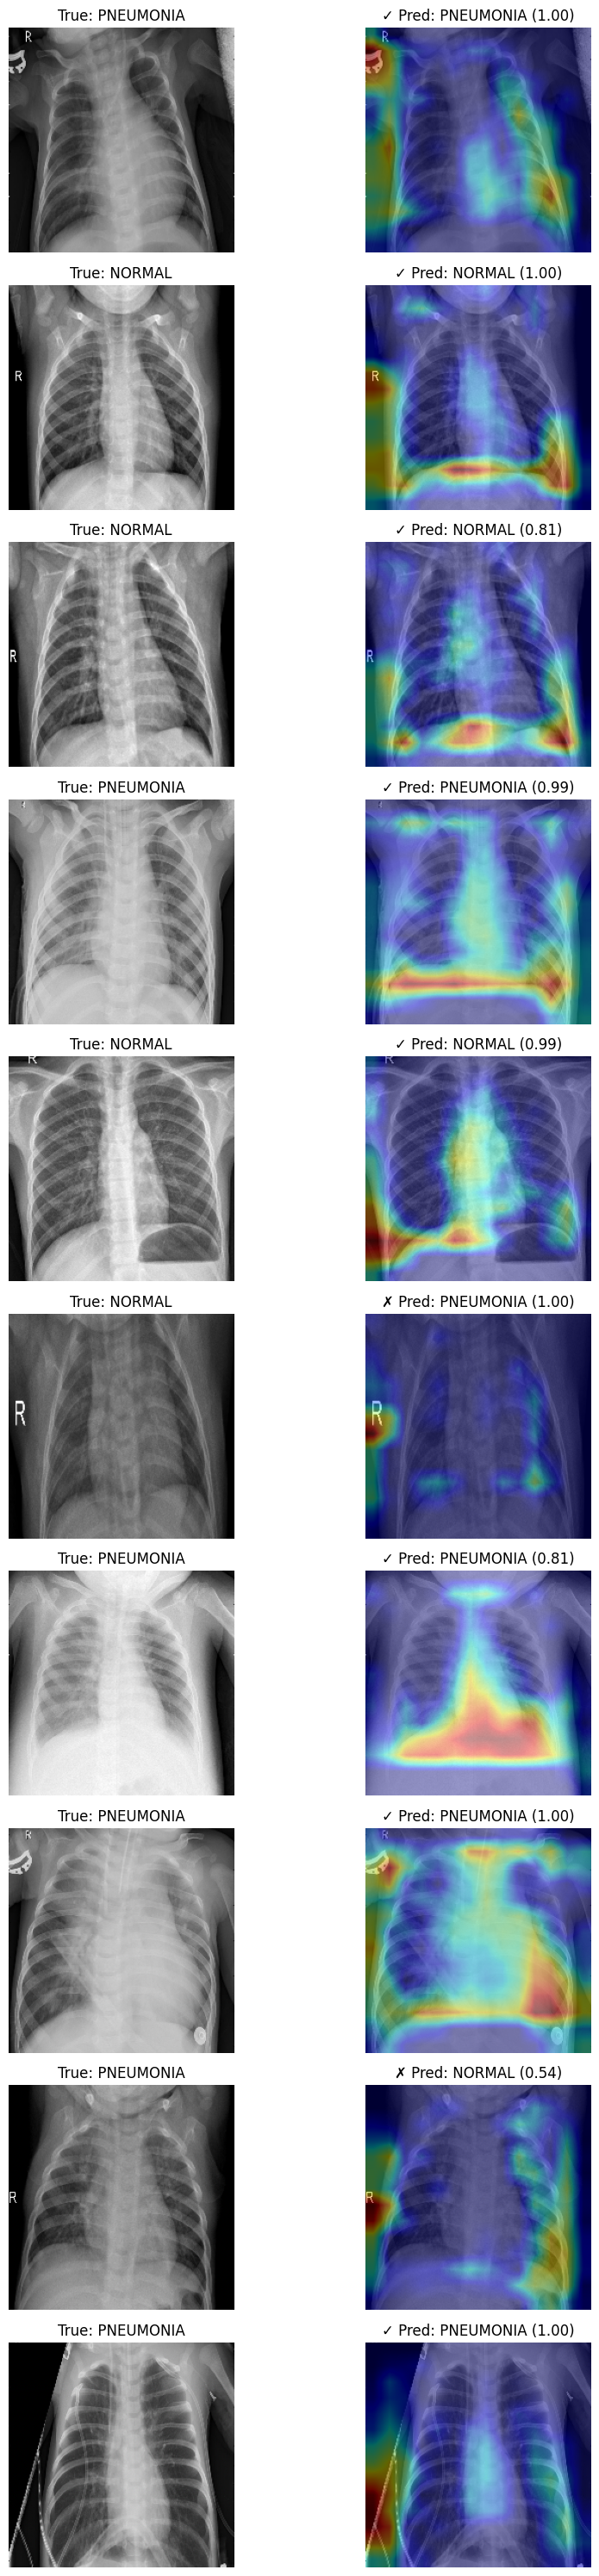

In [85]:
utils.visualize_gradcam_samples(
    model=params_tuned_model,
    dataset=test_dataset,
    last_conv_layer_name=last_conv_layer,
    class_names=["NORMAL", "PNEUMONIA"],
    num_images=10
)
